# Training the on-board model

This is the model that runs on the board, built step by step: same data, same preprocessing and same network as `training/train.py`. The difference is that here 30% of the data is kept aside as a test set, so the accuracy numbers mean something, and we look at what int8 quantization does to the model.

Each row of `data/dataset.csv` is one 5-second window of traffic from one source IP, recorded on the board with `edge_ids.py --record <label>`.

In [1]:
%matplotlib inline
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

tf.keras.utils.set_random_seed(0)
tf.get_logger().setLevel("ERROR")               # the tflite converter is chatty otherwise
tf.keras.config.disable_interactive_logging()

FEATURES = ["pkts", "ports", "syns", "top_port", "held", "nic_pps"]
df = pd.read_csv("../data/dataset.csv")
print(len(df), "windows")
df["label"].value_counts()

167 windows


label
slowloris     54
normal        52
flood         24
scan          19
bruteforce    18
Name: count, dtype: int64

## What each attack looks like

Averages per class. You can almost read the attacks straight off this table: a scan touches lots of ports, a flood shows up in the NIC packet rate (`nic_pps`), brute force keeps hitting one port (`top_port`) and slowloris keeps connections open (`held`).

In [2]:
df.groupby("label")[FEATURES].mean().round(1)

,pkts,ports,syns,top_port,held,nic_pps
label,,,,,,
bruteforce,111.8,2.0,33.6,33.6,2.1,70.4
flood,47.4,1.8,0.0,0.0,0.0,67535.7
normal,28.6,3.0,3.7,3.7,0.0,5.4
scan,91.6,46.0,71.8,2.0,2.4,368.3
slowloris,27.2,1.8,5.8,5.8,14.5,13.1


## Preprocessing

The raw numbers cover a huge range, from zero held connections up to ~100k packets per second, so they go through `log1p` and then get divided by the per-feature maximum to land in 0..1. The board has to repeat this exactly, which is why `train.py` saves those maximums as `scale` in `model.json`.

Here the maximum comes from the training split only, so nothing leaks over from the test set.

In [3]:
labels = sorted(df["label"].unique())
X = np.log1p(df[FEATURES].to_numpy(dtype=np.float32))
y = df["label"].map(labels.index).to_numpy()

idx_train, idx_test = train_test_split(np.arange(len(df)), test_size=0.3, stratify=y, random_state=0)
scale = X[idx_train].max(axis=0)
scale[scale == 0] = 1
X_train, X_test = X[idx_train] / scale, X[idx_test] / scale
y_train, y_test = y[idx_train], y[idx_test]
print("classes:", labels)
print("train", X_train.shape, " test", X_test.shape)

classes: ['bruteforce', 'flood', 'normal', 'scan', 'slowloris']
train (116, 6)  test (51, 6)


## Training

The network is tiny on purpose: 6 inputs, one hidden layer with 24 ReLU units and 5 outputs. Same 400 epochs as `train.py`. The test set is only watched here, nothing gets tuned on it.

293 weights in total


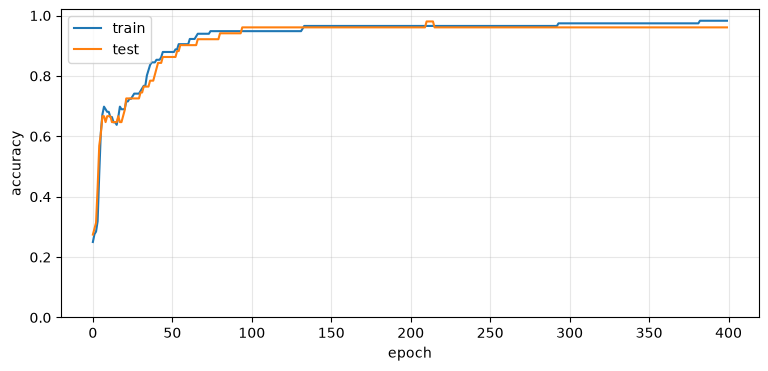

after 400 epochs: train 98.3%, test 96.1%


In [4]:
def make_model(hidden=24):
    model = tf.keras.Sequential([
        tf.keras.layers.Input((len(FEATURES),)),
        tf.keras.layers.Dense(hidden, activation="relu"),
        tf.keras.layers.Dense(len(labels), activation="softmax"),
    ])
    model.compile("adam", "sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

model = make_model()
print(model.count_params(), "weights in total")
hist = model.fit(X_train, y_train, epochs=400, validation_data=(X_test, y_test), verbose=0)

plt.figure(figsize=(9, 4))
plt.plot(hist.history["accuracy"], label="train")
plt.plot(hist.history["val_accuracy"], label="test")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.show()
print(f"after 400 epochs: train {hist.history['accuracy'][-1]:.1%}, test {hist.history['val_accuracy'][-1]:.1%}")

## How big does it need to be?

Quick check on the size of the hidden layer: 5-fold cross-validation on the training split for a few sizes. Takes a minute or two.

In [5]:
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
for hidden in [4, 8, 16, 24, 32]:
    scores = []
    for tr, va in folds.split(X_train, y_train):
        m = make_model(hidden)
        m.fit(X_train[tr], y_train[tr], epochs=400, verbose=0)
        scores.append(m.evaluate(X_train[va], y_train[va], verbose=0)[1])
    print(f"{hidden:2d} hidden units: {np.mean(scores):.1%} +/- {np.std(scores):.1%}")

 4 hidden units: 87.9% +/- 3.2%


 8 hidden units: 91.4% +/- 4.8%


16 hidden units: 94.8% +/- 6.4%


24 hidden units: 96.5% +/- 3.3%


32 hidden units: 96.5% +/- 3.3%


## Test set, float model

              precision    recall  f1-score   support

  bruteforce      1.000     1.000     1.000         6
       flood      0.875     1.000     0.933         7
      normal      1.000     0.938     0.968        16
        scan      1.000     1.000     1.000         6
   slowloris      0.938     0.938     0.938        16

    accuracy                          0.961        51
   macro avg      0.963     0.975     0.968        51
weighted avg      0.963     0.961     0.961        51



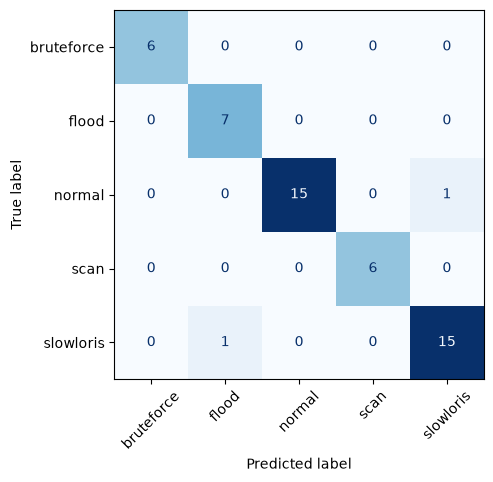

In [6]:
pred = model.predict(X_test, verbose=0).argmax(axis=1)
print(classification_report(y_test, pred, target_names=labels, digits=3))
ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=range(len(labels)), display_labels=labels,
                                        cmap="Blues", colorbar=False)
plt.xticks(rotation=45)
plt.show()

## int8 quantization

The board doesn't run Keras, it runs TensorFlow Lite, and it is much happier with 8-bit integers than with 32-bit floats: every weight takes one byte instead of four and the math becomes integer math, which the Cortex-A7 is quick at.

Quantizing gives every tensor a ruler, a `scale` and a `zero_point`, and stores its values as whole numbers from -128 to 127:

```
real value = scale * (int8 value - zero_point)
```

To pick good rulers the converter needs realistic inputs, so we hand it our training rows (the "representative dataset") and it records the range each layer actually uses. These are the same lines as in `train.py`:

In [7]:
def representative_data():
    for row in X_train:
        yield [row.reshape(1, -1)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]                        # turn quantization on
converter.representative_dataset = representative_data                      # real data to measure ranges on
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]  # int8 ops only
converter.inference_input_type = tf.int8                                    # int8 in
converter.inference_output_type = tf.int8                                   # int8 out
int8_model = converter.convert()
float_model = tf.lite.TFLiteConverter.from_keras_model(model).convert()

weights = [w for w in model.get_weights()]
kernels = sum(w.size for w in weights if w.ndim == 2)
biases = sum(w.size for w in weights if w.ndim == 1)
print(f"weights as float32: {4 * (kernels + biases)} bytes")
print(f"weights as int8:    {kernels + 4 * biases} bytes (biases stay 32-bit)")
print(f"whole .tflite file: {len(float_model)} bytes float32, {len(int8_model)} bytes int8")

weights as float32: 1172 bytes
weights as int8:    380 bytes (biases stay 32-bit)
whole .tflite file: 2928 bytes float32, 3080 bytes int8


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


The rulers the converter picked for the input and the output:

In [8]:
interp = tf.lite.Interpreter(model_content=int8_model)
interp.allocate_tensors()
inp, out = interp.get_input_details()[0], interp.get_output_details()[0]
in_scale, in_zero = inp["quantization"]
out_scale, out_zero = out["quantization"]
print(f"input:  scale {in_scale:.6f} = 1/{1 / in_scale:.0f}, zero point {in_zero}")
print(f"output: scale {out_scale:.6f} = 1/{1 / out_scale:.0f}, zero point {out_zero}")

def run_int8(x):
    # what edge_ids.py does on the board: quantize, run, turn the output back into probabilities
    q = np.clip(np.round(x / in_scale + in_zero), -128, 127).astype(np.int8)
    interp.set_tensor(inp["index"], q.reshape(1, -1))
    interp.invoke()
    raw = interp.get_tensor(out["index"]).reshape(-1)
    return (raw.astype(np.float32) - out_zero) * out_scale

input:  scale 0.003922 = 1/255, zero point -128
output: scale 0.003906 = 1/256, zero point -128


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Our inputs already sit in 0..1, so the input ruler is scale 1/255 with zero point -128: 0.0 is stored as -128, 0.5 as 0 and 1.0 as 127. The output is a probability, so its ruler is 1/256 and an output of 127 means about 99.6%.

One scan window from the test set, all the way through:

In [9]:
i = int(np.flatnonzero(y_test == labels.index("scan"))[0])
x = X_test[i]
q = np.clip(np.round(x / in_scale + in_zero), -128, 127).astype(np.int8)
probs = run_int8(x)
print("model says:", ", ".join(f"{name} {p:.3f}" for name, p in zip(labels, probs)))
pd.DataFrame({"raw": df.iloc[idx_test[i]][FEATURES].astype(float).to_numpy(),
              "log1p / scale": x.round(3), "int8": q}, index=FEATURES)

model says: bruteforce 0.000, flood 0.004, normal 0.000, scan 0.996, slowloris 0.000


,raw,log1p / scale,int8
pkts,121.0,0.919,106
ports,50.0,0.990,125
syns,102.0,0.966,118
top_port,3.0,0.339,-42
held,4.0,0.494,-2
nic_pps,965.0,0.599,25


## Did quantization cost accuracy?

In [10]:
int8_pred = np.array([run_int8(x).argmax() for x in X_test])
print(f"float32 test accuracy: {(pred == y_test).mean():.1%}")
print(f"int8 test accuracy:    {(int8_pred == y_test).mean():.1%}")
print(f"windows where the two disagree: {(pred != int8_pred).sum()} of {len(y_test)}")

float32 test accuracy: 96.1%
int8 test accuracy:    96.1%
windows where the two disagree: 0 of 51


## Wrap-up

- 96.1% on the 51 test windows, for the float and the int8 model alike. The two agree on every single window, so quantization cost nothing here.
- Both misses involve slowloris: one normal window taken for slowloris, one slowloris window taken for flood.
- Accuracy flattens out at 24 hidden units, 32 doesn't buy anything, so 24 it is.
- The weights go from 1,172 to 380 bytes. The whole .tflite file is about 3 KB either way (the int8 one is even a bit bigger, it carries the scales and zero points), because at this size most of the file is TFLite bookkeeping. What counts on the board is that the math is all integer now.

The model on the board is trained exactly like this, just on all 167 windows: `python training/train.py` writes `board/model.tflite` and `board/model.json`, and `./deploy.sh <board-ip>` puts them on the board.